# Homeownership, Debt, and the American Dream

**Team:** Raghav Dewangan, Kartik Gopalani, Kavyan Patel, Rohan Nigam

**Project Proposal**

**Research Question:**
To what extent does the total amount of debt held by a U.S. citizen correlate with the age at which they first purchase a home?

This notebook will explore, analyze, and model this relationship using publicly available datasets.

## 1. Introduction
- Motivation and summary of proposal
- Importance of analyzing debt and homeownership timing

In the current 2026 economic climate, the American Dream of owning a home has shifted from a young adult's reality to an unbecoming fantasy later into adulthood. While high house prices are often blamed, the internal financial health of the average citizen, specifically their non-housing debt, is a silent barrier.

This project is important because it moves beyond just looking at if people buy homes and instead focuses on when they will be able to. By quantifying the delay in acquiring homeownership caused by credit cards, auto loans, and student debt, we can better understand, explore, and visualize the relationship between personal debt, in whatever form that may be, and wealth milestones; in our case, homeownership.

**Research Question:** To what extent does the total amount of debt held by a U.S. citizen correlate with the age at which they first purchase a home?

- Overview of analysis approach

The ultimate goal is to determine whether there is an association between total personal debt and the timing of homeownership. If such a relationship exists, we aim to measure how strong the association is and estimate its magnitude. This leads into our analysis process. We will begin with Exploratory Data Analysis (EDA), using data visualization techniques such as scatter plots and box plots to identify potential patterns or clusters of individuals who purchase homes earlier versus those who experience longer delays. We will also perform data cleaning to address missing values and outliers that could distort the analysis and lead to unreliable results.

---


## 2. Data Acquisition
- Load Federal Reserve SCF, NLSY97, ZHVI, and any supplemental datasets
- Brief description of each dataset

In [43]:
import pandas as pd

In [44]:
nls_duration = pd.read_excel("./data/nls/duration-of-employment-ages-18-to-36.xlsx")
nls_duration

,"Table 1. Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,NaN,NaN,NaN,NaN
1,Characteristic,Average number of jobs for persons ages 18 to ...,NaN,NaN,NaN
2,NaN,Total 2,Ages 18 \nto 23,Ages 24\nto 29,Ages 30\nto 36
3,NaN,NaN,NaN,NaN,NaN
4,"Total, ages 18 to 36 in 1998-2021…………...………......",8.97945,5.10886,3.2566,2.53639
5,Less than a high school diploma ……...…..…......,8.19018,4.51575,2.84659,2.25725
6,"High school graduates, no college 3 …………………",8.97212,5.10014,3.20332,2.49774
7,Some college or associate degree …………………..,9.20508,5.10057,3.18658,2.86122
8,Bachelor's degree and higher 4 ………………………….,9.07869,5.23568,3.42897,2.55733
9,NaN,NaN,NaN,NaN,NaN


#### NLSY97: Number of jobs held (ages 18–36)
This table captures job switching patterns and employment stability over early adulthood.

In [45]:
nls_jobs = pd.read_excel('./data/nls/number-of-jobs-held-ages-18-to-36.xlsx')
nls_jobs

,"Table 1. Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,NaN,NaN,NaN,NaN
1,Characteristic,Average number of jobs for persons ages 18 to ...,NaN,NaN,NaN
2,NaN,Total 2,Ages 18 \nto 23,Ages 24\nto 29,Ages 30\nto 36
3,NaN,NaN,NaN,NaN,NaN
4,"Total, ages 18 to 36 in 1998-2021…………...………......",8.97945,5.10886,3.2566,2.53639
5,Less than a high school diploma ……...…..…......,8.19018,4.51575,2.84659,2.25725
6,"High school graduates, no college 3 …………………",8.97212,5.10014,3.20332,2.49774
7,Some college or associate degree …………………..,9.20508,5.10057,3.18658,2.86122
8,Bachelor's degree and higher 4 ………………………….,9.07869,5.23568,3.42897,2.55733
9,NaN,NaN,NaN,NaN,NaN


#### NLSY97: Partner status (ages 27 and 37)
This table provides household/relationship context that may influence homeownership timing.

In [46]:
nls_partner_status = pd.read_excel('./data/nls/partner-status-at-ages-27-and-37.xlsx')
nls_partner_status

,"Table 1. Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,NaN,NaN,NaN,NaN
1,Characteristic,Average number of jobs for persons ages 18 to ...,NaN,NaN,NaN
2,NaN,Total 2,Ages 18 \nto 23,Ages 24\nto 29,Ages 30\nto 36
3,NaN,NaN,NaN,NaN,NaN
4,"Total, ages 18 to 36 in 1998-2021…………...………......",8.97945,5.10886,3.2566,2.53639
5,Less than a high school diploma ……...…..…......,8.19018,4.51575,2.84659,2.25725
6,"High school graduates, no college 3 …………………",8.97212,5.10014,3.20332,2.49774
7,Some college or associate degree …………………..,9.20508,5.10057,3.18658,2.86122
8,Bachelor's degree and higher 4 ………………………….,9.07869,5.23568,3.42897,2.55733
9,NaN,NaN,NaN,NaN,NaN


#### NLSY97: Percent weeks employed/unemployed/out of labor force (by education, ages 18–36)
This table captures labor-force attachment and unemployment exposure over time.

In [47]:
nls_weeks_employment = pd.read_excel('./data/nls/percent-of-weeks-employment-by-education-ages-18-to-36.xlsx')
nls_weeks_employment

,"Table 1. Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,NaN,NaN,NaN,NaN
1,Characteristic,Average number of jobs for persons ages 18 to ...,NaN,NaN,NaN
2,NaN,Total 2,Ages 18 \nto 23,Ages 24\nto 29,Ages 30\nto 36
3,NaN,NaN,NaN,NaN,NaN
4,"Total, ages 18 to 36 in 1998-2021…………...………......",8.97945,5.10886,3.2566,2.53639
5,Less than a high school diploma ……...…..…......,8.19018,4.51575,2.84659,2.25725
6,"High school graduates, no college 3 …………………",8.97212,5.10014,3.20332,2.49774
7,Some college or associate degree …………………..,9.20508,5.10057,3.18658,2.86122
8,Bachelor's degree and higher 4 ………………………….,9.07869,5.23568,3.42897,2.55733
9,NaN,NaN,NaN,NaN,NaN


#### NLSY97: Training received (ages 18–36)
This table tracks skill-building/training exposure, which can affect earnings and home-buying readiness.

In [48]:
nls_training = pd.read_excel('./data/nls/trainings-received-from-ages-18-to-36.xlsx')
nls_training

,"Table 1. Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,NaN,NaN,NaN,NaN
1,Characteristic,Average number of jobs for persons ages 18 to ...,NaN,NaN,NaN
2,NaN,Total 2,Ages 18 \nto 23,Ages 24\nto 29,Ages 30\nto 36
3,NaN,NaN,NaN,NaN,NaN
4,"Total, ages 18 to 36 in 1998-2021…………...………......",8.97945,5.10886,3.2566,2.53639
5,Less than a high school diploma ……...…..…......,8.19018,4.51575,2.84659,2.25725
6,"High school graduates, no college 3 …………………",8.97212,5.10014,3.20332,2.49774
7,Some college or associate degree …………………..,9.20508,5.10057,3.18658,2.86122
8,Bachelor's degree and higher 4 ………………………….,9.07869,5.23568,3.42897,2.55733
9,NaN,NaN,NaN,NaN,NaN


#### SCFP 2022 (Survey of Consumer Finances Public Data)
This dataset provides household-level financial characteristics (assets, debts, income) used to measure debt burden.

In [49]:
scfp = pd.read_csv('./data/SCFP2022.csv')
scfp

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,3027.956120,2,70,5,9,3,2,2,...,4,2,4,2,1,8,3,3,2,1
1,1,12,3054.900065,2,70,5,9,3,2,2,...,4,2,5,2,1,8,3,3,2,1
2,1,13,3163.637766,2,70,5,9,3,2,2,...,4,2,4,2,1,8,3,3,1,1
3,1,14,3166.228463,2,70,5,9,3,2,2,...,3,2,4,1,1,6,3,2,1,1
4,1,15,3235.624715,2,70,5,9,3,2,2,...,3,2,4,2,1,8,3,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22970,4603,46031,1705.225499,2,40,2,8,2,2,2,...,1,2,1,2,1,1,3,3,2,1
22971,4603,46032,1713.918975,2,40,2,8,2,2,2,...,1,2,1,1,1,1,3,2,1,1
22972,4603,46033,1689.140933,2,40,2,8,2,2,2,...,1,2,1,2,1,1,3,3,2,1
22973,4603,46034,1714.060239,2,40,2,8,2,2,2,...,1,2,1,2,1,1,3,3,2,1


#### USAUCSFRCONDOSMSAMID (FRED Condo Price Index)
This monthly U.S. condo price series is a market-condition control that helps separate debt effects from housing market effects.

In [50]:
usa_condo_index = pd.read_csv('./data/USAUCSFRCONDOSMSAMID.csv')
usa_condo_index.head()

,observation_date,USAUCSFRCONDOSMSAMID
0,2000-01-01,120245.401273
1,2000-02-01,120456.951481
2,2000-03-01,120719.304889
3,2000-04-01,121282.001451
4,2000-05-01,121929.597731


In [51]:
datasets = {
    'nls_duration': nls_duration,
    'nls_jobs': nls_jobs,
    'nls_partner_status': nls_partner_status,
    'nls_weeks_employment': nls_weeks_employment,
    'nls_training': nls_training,
    'scfp': scfp,
    'usa_condo_index': usa_condo_index,
}

for name, d in datasets.items():
    print(f'\n=== {name} ===')
    print('shape:', d.shape)
    print('columns:', d.columns.tolist()[:15])


=== nls_duration ===
shape: (47, 5)
columns: ['Table 1.  Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

=== nls_jobs ===
shape: (47, 5)
columns: ['Table 1.  Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

=== nls_partner_status ===
shape: (47, 5)
columns: ['Table 1.  Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

=== nls_weeks_employment ===
shape: (47, 5)
columns: ['Table 1.  Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino

In [52]:
from pathlib import Path

nls_paths = sorted(Path('./data/nls').glob('*.xlsx'))
for p in nls_paths:
    print(f'\n=== {p.name} ===')
    xls = pd.ExcelFile(p)
    print('sheets:', xls.sheet_names)
    raw = pd.read_excel(p, sheet_name=xls.sheet_names[0], header=None)
    print(raw.head(8).to_string(index=False, header=False))


=== duration-of-employment-ages-18-to-36.xlsx ===
sheets: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
Table 1.  Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age                                                            NaN             NaN            NaN            NaN
                                                                                                                                                             NaN                                                            NaN             NaN            NaN            NaN
                                                                                                                                                  Characteristic Average number of jobs for persons ages 18 to 36 in 1998-20211             NaN            NaN            NaN
                                                                            

In [53]:
from pathlib import Path

nls_paths = sorted(Path('./data/nls').glob('*.xlsx'))
for p in nls_paths:
    xls = pd.ExcelFile(p)
    raw = pd.read_excel(p, sheet_name=xls.sheet_names[0], header=None, nrows=3)
    print(f"{p.name} | sheet={xls.sheet_names[0]} | A1={raw.iloc[0,0]}")

duration-of-employment-ages-18-to-36.xlsx | sheet=T1 | A1=Table 1.  Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age
number-of-jobs-held-ages-18-to-36.xlsx | sheet=T1 | A1=Table 1.  Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age
partner-status-at-ages-27-and-37.xlsx | sheet=T1 | A1=Table 1.  Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age
percent-of-weeks-employment-by-education-ages-18-to-36.xlsx | sheet=T1 | A1=Table 1.  Number of jobs held by individuals from age 18 through age 36 in 1998-2021 by educational attainment, sex, race, Hispanic or Latino ethnicity, and age
trainings-received-from-ages-18-to-36.xlsx | sheet=T1 | A1=Table 1.  Number of jobs held by individuals from age 

---


### Using NLS XLSX Tables Correctly (Important)

These NLS files are summary tables, not person-level panel records. Use them for:
- descriptive context,
- trend visualization,
- robustness/triangulation.

Avoid treating them as individual-level observations for causal claims.

### Standardized NLS Loader

This function reads NLS publication-style XLSX tables, detects a likely header row, removes footnote/title artifacts, and returns:
- a cleaned wide table, and
- a tidy long table (`group`, `measure`, `value`).

In [54]:
import re
from pathlib import Path
import pandas as pd


def _score_header_row(row_values):
    vals = [str(v).strip() for v in row_values if pd.notna(v) and str(v).strip() != '']
    if not vals:
        return -1

    text = ' '.join(vals).lower()
    non_empty = len(vals)

    score = non_empty
    if 'table' in text:
        score -= 3
    if any(k in text for k in ['education', 'age', 'sex', 'race', 'ethnicity', 'hispanic', 'status', 'total']):
        score += 3
    if any('unnamed' in v.lower() for v in vals):
        score -= 1
    return score


def _is_mostly_numeric_header(header_series):
    vals = [str(v).strip() for v in header_series.tolist() if str(v).strip() != '']
    if not vals:
        return True
    numeric_count = 0
    for v in vals:
        try:
            float(v)
            numeric_count += 1
        except Exception:
            pass
    return numeric_count / max(1, len(vals)) >= 0.5


def load_nls_table(path, sheet_name=0, header_row='auto'):
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)
    raw = raw.dropna(axis=0, how='all').dropna(axis=1, how='all').reset_index(drop=True)

    if header_row == 'auto':
        top = min(20, len(raw))
        scored = [(_score_header_row(raw.iloc[i].tolist()), i) for i in range(top)]
        header_idx = max(scored, key=lambda x: x[0])[1]
    else:
        header_idx = int(header_row)

    header = raw.iloc[header_idx].astype(str).str.strip().replace({'nan': ''})

    if _is_mostly_numeric_header(header) and header_idx > 0:
        candidate = raw.iloc[header_idx - 1].astype(str).str.strip().replace({'nan': ''})
        if not _is_mostly_numeric_header(candidate):
            header = candidate
            header_idx = header_idx - 1

    header = [h if h != '' else f'col_{i}' for i, h in enumerate(header)]

    data = raw.iloc[header_idx + 1:].copy()
    data.columns = header
    data = data.dropna(axis=0, how='all').reset_index(drop=True)

    first_col = data.columns[0]
    data = data.rename(columns={first_col: 'group'})

    def clean_group(x):
        s = str(x)
        s = re.sub(r'\s+', ' ', s).strip()
        s = re.sub(r'[\.·…]+$', '', s).strip()
        return s

    data['group'] = data['group'].map(clean_group)

    long_df = data.melt(id_vars=['group'], var_name='measure', value_name='value')
    long_df['value'] = pd.to_numeric(long_df['value'], errors='coerce')
    long_df = long_df.dropna(subset=['value']).reset_index(drop=True)

    return data, long_df


nls_file_map = {
    'duration': './data/nls/duration-of-employment-ages-18-to-36.xlsx',
    'jobs': './data/nls/number-of-jobs-held-ages-18-to-36.xlsx',
    'partner_status': './data/nls/partner-status-at-ages-27-and-37.xlsx',
    'weeks_employment': './data/nls/percent-of-weeks-employment-by-education-ages-18-to-36.xlsx',
    'training': './data/nls/trainings-received-from-ages-18-to-36.xlsx',
}

nls_tables_wide = {}
nls_tables_long = {}

for key, filepath in nls_file_map.items():
    wide_df, long_df = load_nls_table(filepath)
    nls_tables_wide[key] = wide_df
    nls_tables_long[key] = long_df
    print(f"{key:16s} wide={wide_df.shape} | long={long_df.shape}")

nls_tables_long['jobs'].head()

duration         wide=(36, 5) | long=(120, 3)
jobs             wide=(36, 5) | long=(120, 3)
partner_status   wide=(36, 5) | long=(120, 3)
weeks_employment wide=(36, 5) | long=(120, 3)
training         wide=(36, 5) | long=(120, 3)


,group,measure,value
0,"Total, ages 18 to 36 in 1998-2021",Total 2,8.97945
1,Less than a high school diploma,Total 2,8.19018
2,"High school graduates, no college 3",Total 2,8.97212
3,Some college or associate degree,Total 2,9.20508
4,Bachelor's degree and higher 4,Total 2,9.07869


### Understanding the NLSY97 Data in Context of Our Research Question

The National Longitudinal Survey of Youth 1997 (NLSY97) follows the same cohort of individuals from ages 18 to 36, providing a unique longitudinal perspective on how life circumstances evolve over time. While these summary tables don't contain individual-level debt and homeownership data, they provide crucial **contextual factors** that help us understand the broader economic environment in which debt and homeownership decisions are made.

**Why these factors matter for our research question:**
- **Employment stability** (duration, number of jobs) affects income and ability to service debt
- **Training and education** influence earning potential and debt capacity
- **Partner status** impacts household income and financial decision-making
- These factors help us control for confounding variables when analyzing the debt-homeownership relationship

### NLS Table Display and Visualization (EDA)

These cells show each cleaned NLS table and create comparable plots across all NLS datasets.

**Note on `Total 2`:** In these NLS tables, `Total` is the overall estimate across all individuals/groups in the table (for the stated age range and period). The trailing `2` is a table footnote marker from the original BLS/NLS spreadsheet, not part of the metric name itself.

### Exploring NLSY97 Summary Tables: Employment and Economic Context

The cleaned NLS tables below show aggregated statistics across different demographic groups. These patterns help us understand:

1. **Employment Patterns**: How job stability varies by education, age, and demographics
2. **Economic Context**: The labor market conditions that influence both debt accumulation and home-buying capacity
3. **Demographic Variations**: How different groups experience employment, which may correlate with debt levels and homeownership timing

**Connection to our research question**: Individuals with more stable employment and higher education levels typically have:
- Higher incomes → better debt-to-income ratios
- More predictable cash flows → easier mortgage qualification
- Greater financial security → earlier homeownership

This contextual data helps us interpret whether debt delays homeownership, or if both are driven by underlying employment and economic factors.

In [55]:
from IPython.display import display, Markdown

for key, table in nls_tables_wide.items():
    display(Markdown(f"#### {key.replace('_', ' ').title()} (Wide)"))
    display(table)

for key, table in nls_tables_long.items():
    display(Markdown(f"#### {key.replace('_', ' ').title()} (Long/Tidy)"))
    display(table.head(20))

#### Duration (Wide)

,group,Total 2,Ages 18 \nto 23,Ages 24\nto 29,Ages 30\nto 36
0,"Total, ages 18 to 36 in 1998-2021",8.97945,5.10886,3.2566,2.53639
1,Less than a high school diploma,8.19018,4.51575,2.84659,2.25725
2,"High school graduates, no college 3",8.97212,5.10014,3.20332,2.49774
3,Some college or associate degree,9.20508,5.10057,3.18658,2.86122
4,Bachelor's degree and higher 4,9.07869,5.23568,3.42897,2.55733
5,Men,8.85708,4.97102,3.27112,2.57083
6,Less than a high school diploma,8.8461,5.02639,3.12308,2.44157
7,"High school graduates, no college 3",8.98602,5.07449,3.26398,2.55068
8,Some college or associate degree,9.04291,4.96008,3.24711,2.89346
9,Bachelor's degree and higher 4,8.57395,4.77231,3.32547,2.55007


#### Jobs (Wide)

,group,Total 2,Ages 18 \nto 23,Ages 24\nto 29,Ages 30\nto 36
0,"Total, ages 18 to 36 in 1998-2021",8.97945,5.10886,3.2566,2.53639
1,Less than a high school diploma,8.19018,4.51575,2.84659,2.25725
2,"High school graduates, no college 3",8.97212,5.10014,3.20332,2.49774
3,Some college or associate degree,9.20508,5.10057,3.18658,2.86122
4,Bachelor's degree and higher 4,9.07869,5.23568,3.42897,2.55733
5,Men,8.85708,4.97102,3.27112,2.57083
6,Less than a high school diploma,8.8461,5.02639,3.12308,2.44157
7,"High school graduates, no college 3",8.98602,5.07449,3.26398,2.55068
8,Some college or associate degree,9.04291,4.96008,3.24711,2.89346
9,Bachelor's degree and higher 4,8.57395,4.77231,3.32547,2.55007


#### Partner Status (Wide)

...

,group,measure,value
0,"Total, ages 18 to 36 in 1998-2021",Total 2,8.97945
1,Less than a high school diploma,Total 2,8.19018
2,"High school graduates, no college 3",Total 2,8.97212
3,Some college or associate degree,Total 2,9.20508
4,Bachelor's degree and higher 4,Total 2,9.07869
5,Men,Total 2,8.85708
6,Less than a high school diploma,Total 2,8.84610
7,"High school graduates, no college 3",Total 2,8.98602
8,Some college or associate degree,Total 2,9.04291
9,Bachelor's degree and higher 4,Total 2,8.57395


#### Weeks Employment (Long/Tidy)

,group,measure,value
0,"Total, ages 18 to 36 in 1998-2021",Total 2,8.97945
1,Less than a high school diploma,Total 2,8.19018
2,"High school graduates, no college 3",Total 2,8.97212
3,Some college or associate degree,Total 2,9.20508
4,Bachelor's degree and higher 4,Total 2,9.07869
5,Men,Total 2,8.85708
6,Less than a high school diploma,Total 2,8.84610
7,"High school graduates, no college 3",Total 2,8.98602
8,Some college or associate degree,Total 2,9.04291
9,Bachelor's degree and higher 4,Total 2,8.57395


#### Training (Long/Tidy)

,group,measure,value
0,"Total, ages 18 to 36 in 1998-2021",Total 2,8.97945
1,Less than a high school diploma,Total 2,8.19018
2,"High school graduates, no college 3",Total 2,8.97212
3,Some college or associate degree,Total 2,9.20508
4,Bachelor's degree and higher 4,Total 2,9.07869
5,Men,Total 2,8.85708
6,Less than a high school diploma,Total 2,8.84610
7,"High school graduates, no college 3",Total 2,8.98602
8,Some college or associate degree,Total 2,9.04291
9,Bachelor's degree and higher 4,Total 2,8.57395


### Visualizing Employment and Economic Patterns

The visualizations below show key patterns from the NLSY97 data. These bar charts help us identify:

- **Which demographic groups** experience different employment outcomes
- **How employment metrics vary** across education levels, age groups, and other characteristics
- **Potential confounding factors** we need to account for when analyzing debt and homeownership

**Key insight for our analysis**: If we observe that certain groups (e.g., lower education, more job switching) also have higher debt and later homeownership, we need to carefully distinguish whether:
- Debt directly causes delayed homeownership, OR
- Both debt and delayed homeownership are consequences of underlying employment/economic factors

This is why we'll use the SCF data (with actual debt measurements) combined with these contextual NLS patterns to build a more robust model.

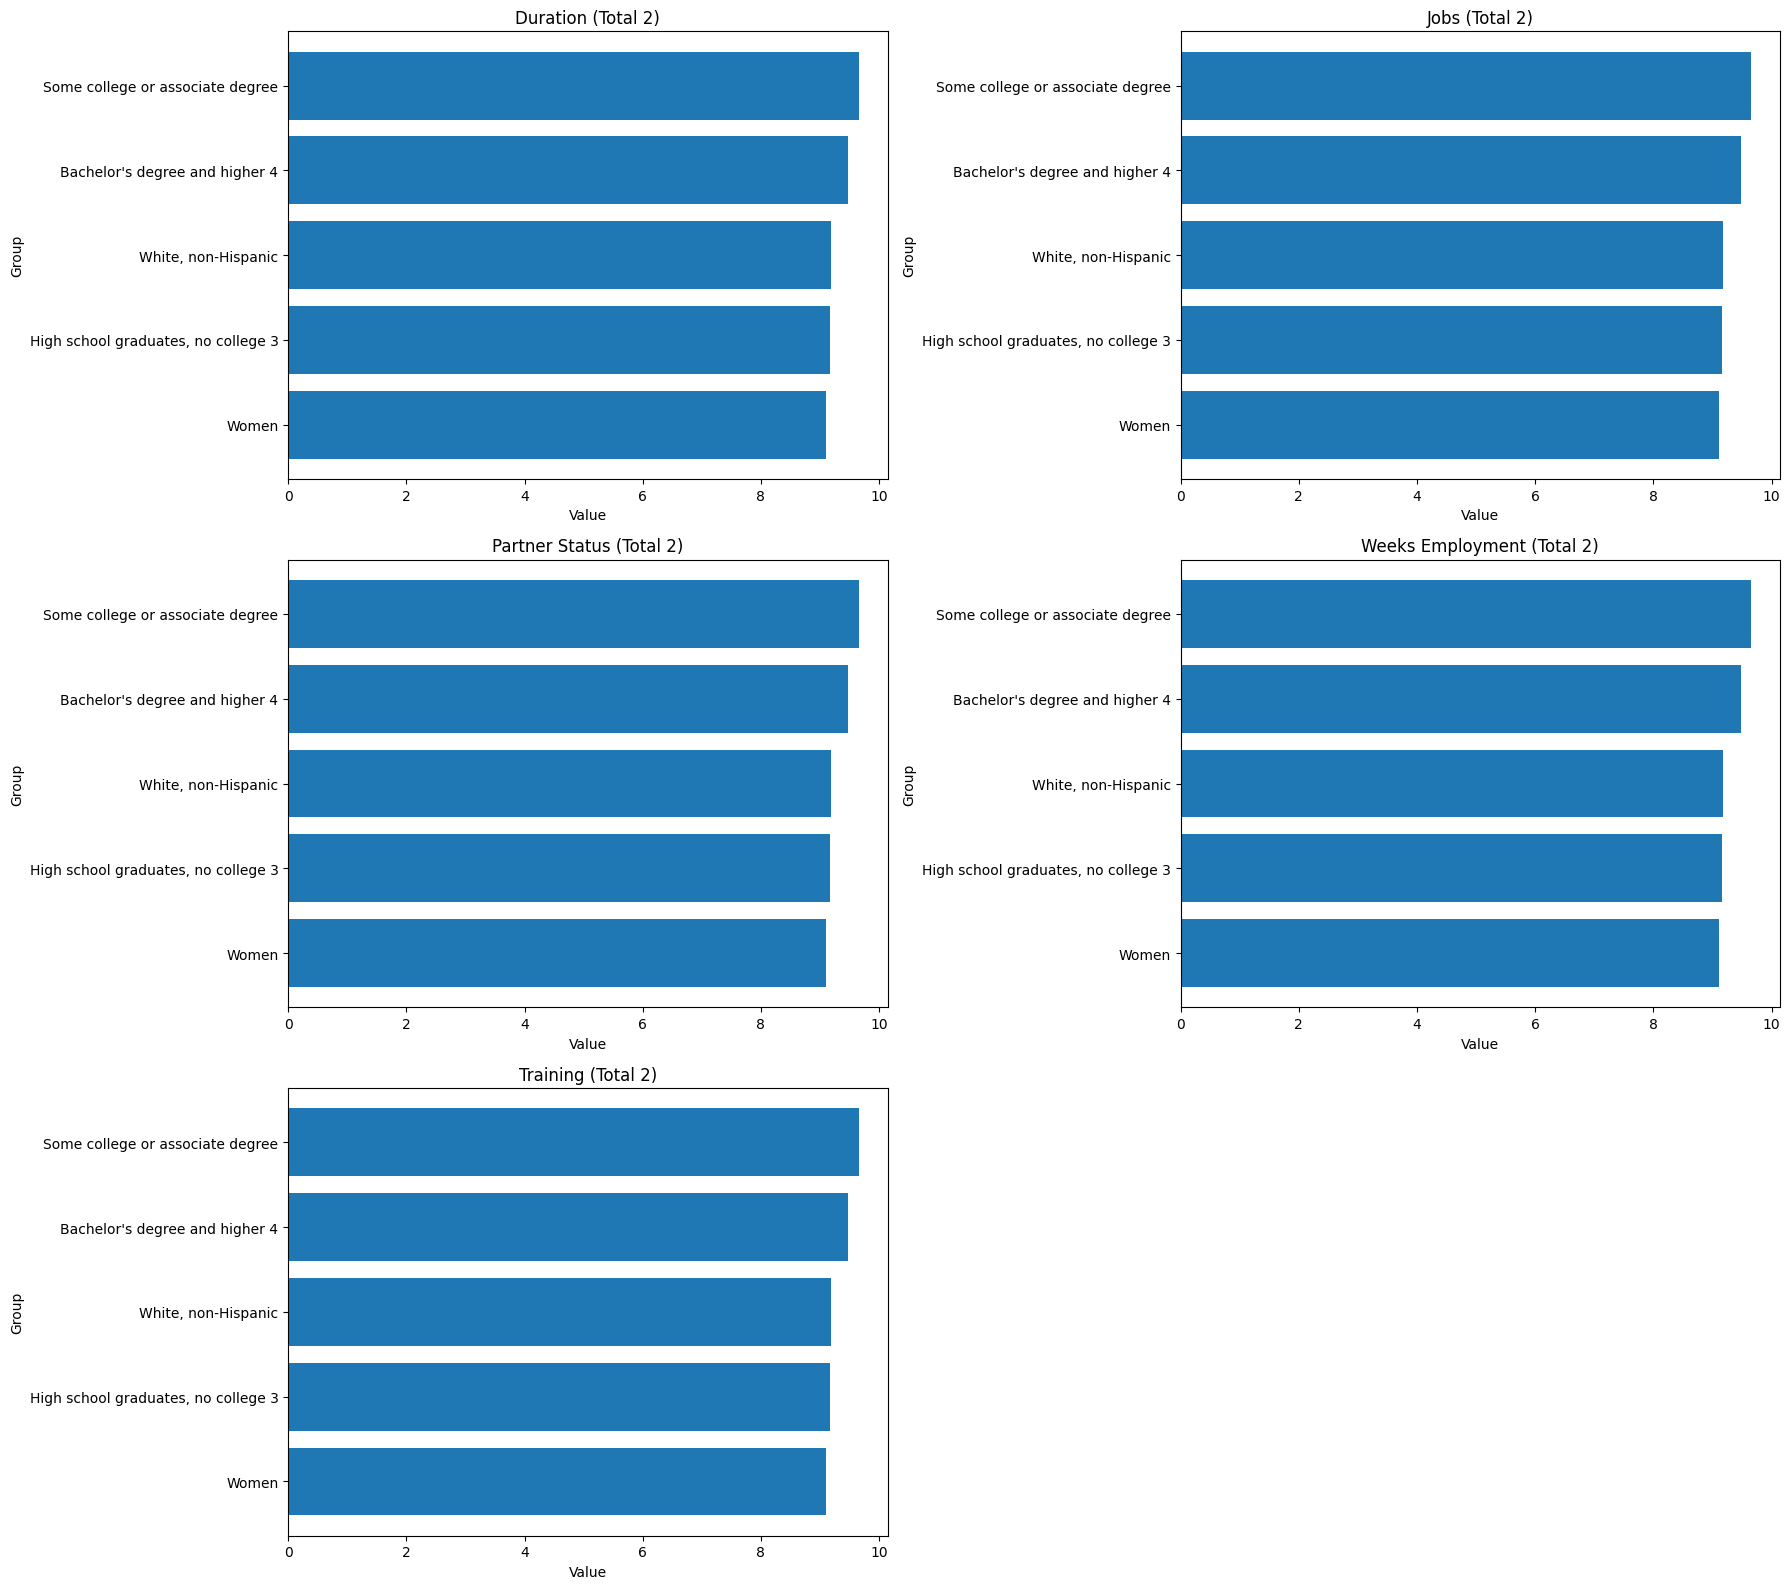

In [56]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for i, (key, long_df) in enumerate(nls_tables_long.items()):
    ax = axes[i]

    measures = [m for m in long_df['measure'].dropna().unique().tolist() if str(m).strip() != '']
    chosen_measure = 'Total 2' if 'Total 2' in measures else measures[0]

    plot_df = long_df[long_df['measure'] == chosen_measure].copy()
    plot_df = plot_df[~plot_df['group'].str.contains('total', case=False, na=False)]
    plot_df = plot_df.sort_values('value', ascending=False).head(12)

    ax.barh(plot_df['group'], plot_df['value'])
    ax.invert_yaxis()
    ax.set_title(f"{key.replace('_', ' ').title()} ({chosen_measure})")
    ax.set_xlabel('Value')
    ax.set_ylabel('Group')

if len(nls_tables_long) < len(axes):
    for j in range(len(nls_tables_long), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [57]:
import numpy as np

def clean_nls_summary_table(path):
    raw = pd.read_excel(path, header=None)
    raw = raw.dropna(axis=0, how='all').dropna(axis=1, how='all').reset_index(drop=True)

    candidate_rows = []
    for i in range(min(12, len(raw))):
        row = raw.iloc[i]
        non_null = row.notna().sum()
        text = ' '.join(str(v) for v in row.dropna().astype(str).tolist()).lower()
        score = non_null
        if 'table' in text:
            score -= 3
        if 'age' in text or 'education' in text or 'sex' in text:
            score += 2
        candidate_rows.append((score, i))

    header_idx = sorted(candidate_rows, reverse=True)[0][1]
    header = raw.iloc[header_idx].astype(str).str.strip().replace({'nan': ''})

    df = raw.iloc[header_idx + 1:].copy()
    df.columns = header
    df = df.loc[:, df.columns != '']
    df = df.dropna(axis=0, how='all').reset_index(drop=True)

    first_col = df.columns[0]
    df = df.rename(columns={first_col: 'group'})

    long_df = df.melt(id_vars=['group'], var_name='metric_or_age', value_name='value')
    long_df['value'] = pd.to_numeric(long_df['value'], errors='coerce')
    long_df = long_df.dropna(subset=['value']).reset_index(drop=True)
    return df, long_df

nls_files = {
    'duration': './data/nls/duration-of-employment-ages-18-to-36.xlsx',
    'jobs': './data/nls/number-of-jobs-held-ages-18-to-36.xlsx',
    'partner_status': './data/nls/partner-status-at-ages-27-and-37.xlsx',
    'weeks_employment': './data/nls/percent-of-weeks-employment-by-education-ages-18-to-36.xlsx',
    'training': './data/nls/trainings-received-from-ages-18-to-36.xlsx',
}

nls_wide = {}
nls_long = {}
for name, path in nls_files.items():
    wide, long = clean_nls_summary_table(path)
    nls_wide[name] = wide
    nls_long[name] = long
    print(f"{name}: wide={wide.shape}, long={long.shape}")

nls_long['jobs'].head()

duration: wide=(35, 5), long=(116, 3)
jobs: wide=(35, 5), long=(116, 3)
partner_status: wide=(35, 5), long=(116, 3)
weeks_employment: wide=(35, 5), long=(116, 3)
training: wide=(35, 5), long=(116, 3)


,group,metric_or_age,value
0,Less than a high school diploma ……...…..…......,8.97945,8.19018
1,"High school graduates, no college 3 …………………",8.97945,8.97212
2,Some college or associate degree …………………..,8.97945,9.20508
3,Bachelor's degree and higher 4 ………………………….,8.97945,9.07869
4,Men ………………....……...…...…...……….……………..,8.97945,8.85708


### Data Quality Checks: Verifying NLS File Integrity

Before proceeding with analysis, we verify the integrity and structure of our NLS data files. The checks below ensure:
- Files are correctly loaded and accessible
- File structures are consistent across datasets
- We can reliably merge or reference these summary statistics in our analysis

**Next steps**: With the NLS contextual data cleaned and verified, we'll now turn to the **Survey of Consumer Finances (SCF)** data, which contains the actual debt measurements and homeownership information needed to directly test our research question.

In [58]:
import hashlib
from pathlib import Path

for p in sorted(Path('./data/nls').glob('*.xlsx')):
    file_hash = hashlib.md5(p.read_bytes()).hexdigest()
    print(p.name, file_hash)

duration-of-employment-ages-18-to-36.xlsx 0cc304269413650f48102172d055bb91
number-of-jobs-held-ages-18-to-36.xlsx fcadb5aa73dc8a57d5aa1eadb3e9809e
partner-status-at-ages-27-and-37.xlsx ca57522d733650a0c7c05afaa01d230e
percent-of-weeks-employment-by-education-ages-18-to-36.xlsx 671f4e7ee9da219f5dc30009c6665f03
trainings-received-from-ages-18-to-36.xlsx 0510b31f6383565dddeb4868fb766868


In [59]:
from pathlib import Path

for p in sorted(Path('./data/nls').glob('*.xlsx')):
    xls = pd.ExcelFile(p)
    print(p.name, '->', xls.sheet_names)

duration-of-employment-ages-18-to-36.xlsx -> ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
number-of-jobs-held-ages-18-to-36.xlsx -> ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
partner-status-at-ages-27-and-37.xlsx -> ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
percent-of-weeks-employment-by-education-ages-18-to-36.xlsx -> ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
trainings-received-from-ages-18-to-36.xlsx -> ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']


## 3. Data Exploration & Cleaning

### Transitioning to Core Analysis Data

Now that we've established the economic and employment context from NLSY97, we turn to the **Survey of Consumer Finances (SCF)**, which provides the direct measurements we need:

- **Total debt amounts** (credit cards, auto loans, student debt, etc.)
- **Homeownership status and timing**
- **Income and assets**
- **Demographic characteristics**

This is where we'll perform the core EDA to answer our research question: *To what extent does total debt correlate with the age at which someone first purchases a home?*

**Our EDA approach** (as outlined in the proposal):
1. **Summary statistics** to understand the distribution of debt and homeownership ages
2. **Missing value analysis** to ensure data quality
3. **Outlier detection and handling** to prevent skewed results
4. **Visualizations**: scatter plots, box plots, and debt binning to identify patterns
5. **Debt-to-income ratios** to find potential tipping points where homeownership becomes less likely

---


### Comprehensive Modeling Workflow (SCF-centered)

Because SCF is cross-sectional, we cannot directly observe each person's exact age at first home purchase. We therefore use a **two-model strategy** that still answers the proposal question in a defensible way:

1. **Owner-age model (weighted OLS):** among homeowners (`OWN == 1`), estimate how debt burden is associated with current age while controlling for income, education, race, sex, and net worth.
2. **Ownership-timing proxy model (weighted logistic):** on the full sample, predict `OWN` from age, debt burden, and controls. Then estimate the age where predicted ownership probability reaches 50% at low vs high debt levels.

This yields both:
- effect-size estimates (association strength), and
- an interpretable timing proxy (estimated delay in ownership age, in years).

We use SCF survey weights (`WGT`) and robust inference where applicable.

#### Step 1 — Build the Modeling Dataset

At a high level, we first construct a clean analysis table from SCF that includes our outcome variables, debt measures, controls, and survey weights.

This step ensures all downstream models are trained on the same filtered sample and consistently engineered features (for example, log-transformed debt/income/net worth).

In [60]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Ensure SCF data is available in a fresh kernel
if 'scfp' not in globals():
    scfp = pd.read_csv('./data/SCFP2022.csv')

# Build SCF modeling table
scf_model_cols = [
    'AGE', 'OWN', 'DEBT', 'DEBT2INC', 'INCOME', 'EDUC', 'RACE', 'HHSEX', 'NETWORTH', 'WGT'
 ]

model_df = scfp[scf_model_cols].copy()

# Numeric conversion + basic cleaning
for c in scf_model_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors='coerce')

# Keep valid rows for core variables
model_df = model_df.dropna(subset=['AGE', 'OWN', 'DEBT', 'DEBT2INC', 'INCOME', 'WGT']).copy()
model_df = model_df[(model_df['WGT'] > 0) & (model_df['AGE'] >= 18)].copy()

# Feature engineering
model_df['log_debt'] = np.log1p(np.clip(model_df['DEBT'], a_min=0, a_max=None))
model_df['log_income'] = np.log1p(np.clip(model_df['INCOME'], a_min=0, a_max=None))
model_df['log_networth'] = np.log1p(np.clip(model_df['NETWORTH'], a_min=0, a_max=None))

# Owner subset for age model
owners_df = model_df[model_df['OWN'] == 1].copy()

print('Model table shape:', model_df.shape)
print('Owner subset shape:', owners_df.shape)
model_df[['AGE','OWN','DEBT','DEBT2INC','INCOME','WGT','log_debt']].head()

Model table shape: (22975, 13)
Owner subset shape: (19590, 13)


,AGE,OWN,DEBT,DEBT2INC,INCOME,WGT,log_debt
0,70,1,195000,5.025160,38804.734469,3027.956120,12.180760
1,70,1,213000,5.566549,38264.278557,3054.900065,12.269052
2,70,1,279000,7.728006,36102.454910,3163.637766,12.538971
3,70,1,549000,16.384017,33508.266533,3166.228463,13.215856
4,70,1,223000,6.270739,35561.998998,3235.624715,12.314932


#### Step 1b — Variable Selection (Backward Elimination)

To keep the model parsimonious and transparent, we run backward variable selection on the weighted OLS specification.

At a high level, we start with the full set of candidate terms, iteratively remove the least useful term (highest non-significant p-value), and stop once all remaining removable terms are significant at $\alpha = 0.05$.

> We keep `log_debt` in the model throughout, since it is the primary variable tied directly to the research question.

In [66]:
# Backward variable selection for weighted OLS (keeping log_debt fixed)
alpha_remove = 0.05
forced_terms = {'log_debt'}

candidate_terms = [
    'log_debt',
    'DEBT2INC',
    'log_income',
    'log_networth',
    'C(EDUC)',
    'C(RACE)',
    'C(HHSEX)'
]

def make_formula(terms):
    return 'AGE ~ ' + ' + '.join(terms)

current_terms = candidate_terms.copy()
selection_steps = []

while True:
    current_formula = make_formula(current_terms)
    current_fit = smf.wls(
        current_formula,
        data=owners_df,
        weights=owners_df['WGT']
).fit(cov_type='HC3')

    term_table = current_fit.wald_test_terms(skip_single=False).summary_frame()
    p_col = 'P>chi2' if 'P>chi2' in term_table.columns else term_table.columns[-1]
    term_pvals = term_table[p_col].astype(float)

    removable_terms = [t for t in current_terms if t not in forced_terms]
    removable_pvals = term_pvals.loc[term_pvals.index.intersection(removable_terms)]

    if removable_pvals.empty:
        break

    worst_term = removable_pvals.idxmax()
    worst_p = float(removable_pvals.max())

    selection_steps.append({
        'formula': current_formula,
        'removed_term': worst_term if worst_p > alpha_remove else None,
        'max_removable_p': worst_p,
    })

    if worst_p <= alpha_remove:
        break

    current_terms.remove(worst_term)

selected_ols_terms = current_terms.copy()
selected_ols_formula = make_formula(selected_ols_terms)

selection_trace = pd.DataFrame(selection_steps)
print('Selected OLS formula:', selected_ols_formula)
display(selection_trace.tail(10))

c:\Users\ragha\miniforge3\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


Selected OLS formula: AGE ~ log_debt + log_income + log_networth + C(EDUC) + C(RACE) + C(HHSEX)


c:\Users\ragha\miniforge3\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


,formula,removed_term,max_removable_p
0,AGE ~ log_debt + DEBT2INC + log_income + log_n...,DEBT2INC,0.905363
1,AGE ~ log_debt + log_income + log_networth + C...,None,0.000344


#### Step 2 — Estimate the Core Association (Weighted OLS)

Next, we fit a weighted linear model on homeowners only to estimate how debt burden is associated with homeowner age after adjusting for key confounders.

This provides an interpretable coefficient-level view (direction, size, and significance) of the debt–age relationship.

In [67]:
# 1) Weighted OLS among homeowners: association between debt burden and age
full_ols_formula = "AGE ~ log_debt + DEBT2INC + log_income + log_networth + C(EDUC) + C(RACE) + C(HHSEX)"
ols_formula = selected_ols_formula if 'selected_ols_formula' in globals() else full_ols_formula

print('Using OLS formula:', ols_formula)

ols_fit = smf.wls(
    ols_formula,
    data=owners_df,
    weights=owners_df['WGT']
).fit(cov_type='HC3')

print(ols_fit.summary())

# Key coefficients table
ols_key = ols_fit.params.to_frame('coef').join(
    ols_fit.bse.to_frame('std_err')
).join(
    ols_fit.pvalues.to_frame('p_value')
)
ols_key.loc[[idx for idx in ols_key.index if idx in ['log_debt', 'DEBT2INC', 'log_income', 'log_networth']]]

Using OLS formula: AGE ~ log_debt + log_income + log_networth + C(EDUC) + C(RACE) + C(HHSEX)
                            WLS Regression Results                            
Dep. Variable:                    AGE   R-squared:                       0.230
Model:                            WLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     177.0
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:54:10   Log-Likelihood:                -87949.
No. Observations:               19590   AIC:                         1.759e+05
Df Residuals:                   19567   BIC:                         1.761e+05
Df Model:                          22                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

,coef,std_err,p_value
log_debt,-0.818491,0.033985,3.677554e-128
log_income,-0.583802,0.163091,3.441075e-04
log_networth,1.629880,0.051578,3.622527e-219


#### Step 2b — Formal Hypothesis Test

To connect the model directly back to the research question, we perform a formal test on the `log_debt` coefficient in the weighted OLS model.

At a high level, this asks whether debt burden has a statistically detectable association with homeowner age after controlling for income, education, race, sex, and net worth.

We test:
- $H_0$: $\beta_{\log(\mathrm{debt})} = 0$
- $H_A$: $\beta_{\log(\mathrm{debt})} \neq 0$

If the p-value is below $\alpha = 0.05$, we reject the null hypothesis and conclude that debt burden is significantly associated with age in this model.

In [68]:
# Formal hypothesis test for the debt coefficient in the weighted OLS model
alpha = 0.05
test_term = 'log_debt'

beta_hat = float(ols_fit.params[test_term])
std_err = float(ols_fit.bse[test_term])
test_stat = float(ols_fit.tvalues[test_term])
p_value = float(ols_fit.pvalues[test_term])
ci_low, ci_high = [float(x) for x in ols_fit.conf_int().loc[test_term]]
reject_null = p_value < alpha

hypothesis_test_summary = pd.DataFrame({
    'term': [test_term],
    'estimate': [beta_hat],
    'std_err': [std_err],
    'test_statistic': [test_stat],
    'p_value': [p_value],
    'ci_lower_95': [ci_low],
    'ci_upper_95': [ci_high],
    'alpha': [alpha],
    'reject_null': [reject_null],
})

decision_text = 'Reject $H_0$' if reject_null else 'Fail to reject $H_0$'
interpretation_text = (
    f"Debt burden is {'significantly' if reject_null else 'not significantly'} associated with homeowner age "
    f"in the weighted OLS model (estimate={beta_hat:.3f}, test statistic={test_stat:.3f}, "
    f"p-value={p_value:.3e}, 95% CI=[{ci_low:.3f}, {ci_high:.3f}])."
 )

print(decision_text)
print(interpretation_text)
hypothesis_test_summary

Reject $H_0$
Debt burden is significantly associated with homeowner age in the weighted OLS model (estimate=-0.818, test statistic=-24.084, p-value=3.678e-128, 95% CI=[-0.885, -0.752]).


,term,estimate,std_err,test_statistic,p_value,ci_lower_95,ci_upper_95,alpha,reject_null
0,log_debt,-0.818491,0.033985,-24.084002,3.677554e-128,-0.8851,-0.751882,0.05,True


**Interpretation note.** This test gives formal inferential evidence that debt burden is associated with age **within the homeowner sample**, after controlling for key financial and demographic variables. Because SCF is cross-sectional and does not directly record each respondent's age at first home purchase, this result should be interpreted as evidence of association rather than a causal estimate of how many years debt delays first-time homeownership. The logistic model and probability-gap analysis complement this test by describing how ownership likelihood varies across debt profiles.

#### Step 3 — Model Ownership Probability and Timing Proxy

We then train a weighted logistic model on the full sample to estimate homeownership probability across age and debt profiles.

At a high level, this lets us report model quality (cross-validated ROC-AUC/Brier) and translate predictions into an intuitive timing proxy (or probability-gap fallback) for the research question.

In [63]:
# 2) Weighted logistic model on full sample + CV + timing proxy
logit_df = model_df.copy()
logit_df['age_x_logdebt'] = logit_df['AGE'] * logit_df['log_debt']

feature_cols = ['AGE', 'log_debt', 'DEBT2INC', 'log_income', 'log_networth', 'age_x_logdebt', 'EDUC', 'RACE', 'HHSEX']
X = logit_df[feature_cols]
y = logit_df['OWN'].astype(int).values
w = logit_df['WGT'].values

num_cols = ['AGE', 'log_debt', 'DEBT2INC', 'log_income', 'log_networth', 'age_x_logdebt']
cat_cols = ['EDUC', 'RACE', 'HHSEX']

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols),
    ]
)

logit_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=2000))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
try:
    cv_scores = cross_validate(
        logit_pipe, X, y, cv=cv, scoring=['roc_auc', 'neg_brier_score'],
        params={'clf__sample_weight': w}
    )
except TypeError:
    cv_scores = cross_validate(
        logit_pipe, X, y, cv=cv, scoring=['roc_auc', 'neg_brier_score'],
        fit_params={'clf__sample_weight': w}
    )

print('5-fold ROC-AUC:', np.mean(cv_scores['test_roc_auc']))
print('5-fold Brier score:', -np.mean(cv_scores['test_neg_brier_score']))

# Fit once on full data for interpretation and timing-proxy calculation
logit_pipe.fit(X, y, clf__sample_weight=w)

# Predicted ownership-probability at each age for chosen debt levels
debt_q25 = np.quantile(logit_df['log_debt'], 0.25)
debt_q75 = np.quantile(logit_df['log_debt'], 0.75)

template = {
    'DEBT2INC': np.median(logit_df['DEBT2INC']),
    'log_income': np.median(logit_df['log_income']),
    'log_networth': np.median(logit_df['log_networth']),
    'EDUC': int(np.round(logit_df['EDUC'].median())),
    'RACE': int(np.round(logit_df['RACE'].median())),
    'HHSEX': int(np.round(logit_df['HHSEX'].median())),
}

def ownership_curve(log_debt_level):
    ages = np.arange(20, 71)
    grid = pd.DataFrame({
        'AGE': ages,
        'log_debt': log_debt_level,
        'DEBT2INC': template['DEBT2INC'],
        'log_income': template['log_income'],
        'log_networth': template['log_networth'],
        'EDUC': template['EDUC'],
        'RACE': template['RACE'],
        'HHSEX': template['HHSEX'],
    })
    grid['age_x_logdebt'] = grid['AGE'] * grid['log_debt']
    p = logit_pipe.predict_proba(grid[feature_cols])[:, 1]
    return ages, p

def crossing_age(ages, probs, target):
    diff = probs - target
    idx = np.where(np.diff(np.sign(diff)) != 0)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    x0, x1 = ages[i], ages[i + 1]
    y0, y1 = probs[i], probs[i + 1]
    if y1 == y0:
        return float(x1)
    return float(x0 + (target - y0) * (x1 - x0) / (y1 - y0))

ages_low, p_low = ownership_curve(debt_q25)
ages_high, p_high = ownership_curve(debt_q75)

# Timing proxy at reference age
ref_age = 35
ref_idx = np.where(ages_low == ref_age)[0][0]
p_low_ref = p_low[ref_idx]
p_high_ref = p_high[ref_idx]

eq_age_high_for_low = crossing_age(ages_high, p_high, p_low_ref)
eq_age_low_for_high = crossing_age(ages_low, p_low, p_high_ref)

shift_high_minus_low = eq_age_high_for_low - ref_age if not np.isnan(eq_age_high_for_low) else np.nan
shift_low_minus_high = eq_age_low_for_high - ref_age if not np.isnan(eq_age_low_for_high) else np.nan
prob_gap_at_ref_age = p_high_ref - p_low_ref

print(f'Predicted ownership at age {ref_age} (low debt):  {p_low_ref:.3f}')
print(f'Predicted ownership at age {ref_age} (high debt): {p_high_ref:.3f}')

if not np.isnan(shift_high_minus_low):
    print(f'Equivalent-age shift (high debt relative to low): {shift_high_minus_low:.2f} years')
elif not np.isnan(shift_low_minus_high):
    print(f'Equivalent-age shift (low debt relative to high): {shift_low_minus_high:.2f} years')
else:
    print('Equivalent-age shift not identifiable in [20,70]; reporting probability gap instead.')
    print(f'Ownership probability gap at age {ref_age} (high - low debt): {prob_gap_at_ref_age:.3f}')

pd.DataFrame({
    'age': ages_low,
    'p_own_low_debt_q25': p_low,
    'p_own_high_debt_q75': p_high,
}).head()

5-fold ROC-AUC: 0.7778080612947175
5-fold Brier score: 0.09512912277099654
Predicted ownership at age 35 (low debt):  0.867
Predicted ownership at age 35 (high debt): 0.985
Equivalent-age shift not identifiable in [20,70]; reporting probability gap instead.
Ownership probability gap at age 35 (high - low debt): 0.118


,age,p_own_low_debt_q25,p_own_high_debt_q75
0,20,0.842977,0.987773
1,21,0.844694,0.987597
2,22,0.846396,0.987419
3,23,0.848083,0.987238
4,24,0.849755,0.987054


### How to Interpret These Modeling Outputs

- **OLS (`OWN==1`)** gives partial associations between debt burden and homeowner age, controlling for demographics and finances.
- **Logistic (`OWN` on full sample)** provides predictive evidence for ownership likelihood across age/debt profiles.
- If an equivalent-age shift is not identifiable (as in this run), use the **ownership probability gap at a reference age** as the timing proxy.
- Because this is observational cross-sectional data, interpret as association rather than causation.

### Model Visualization + Section 6 Summary Artifacts

The cells below create:
- an ownership-probability curve plot (low vs high debt), and
- a compact, publication-ready summary table of key model outputs for the Results section.

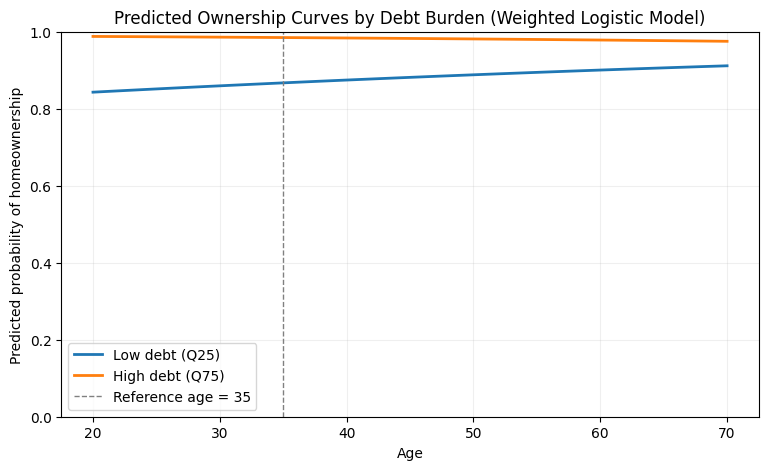

Section 6 artifact created: results_table_section6

OLS coefficient summary:


,term,coef,std_err,p_value,model
0,log_debt,-0.819331,0.034727,4.483661e-123,Weighted OLS (owners only)
1,DEBT2INC,0.003539,0.029768,9.053634e-01,Weighted OLS (owners only)
2,log_income,-0.581125,0.168727,5.727931e-04,Weighted OLS (owners only)
3,log_networth,1.629653,0.051660,2.062521e-218,Weighted OLS (owners only)



Logistic/timing summary:


,metric,value
0,Logistic 5-fold ROC-AUC,0.777808
1,Logistic 5-fold Brier score,0.095129
2,Predicted OWN at age 35 (low debt Q25),0.867156
3,Predicted OWN at age 35 (high debt Q75),0.984858
4,Ownership probability gap at age 35 (high-low),0.117702
5,"Equivalent-age shift identifiable in [20,70]",NaN


In [64]:
import matplotlib.pyplot as plt

# ---- Visualization: ownership probability curves ----
curve_df = pd.DataFrame({
    'age': ages_low,
    'Low debt (Q25)': p_low,
    'High debt (Q75)': p_high,
})

plt.figure(figsize=(9, 5))
plt.plot(curve_df['age'], curve_df['Low debt (Q25)'], label='Low debt (Q25)', linewidth=2)
plt.plot(curve_df['age'], curve_df['High debt (Q75)'], label='High debt (Q75)', linewidth=2)
plt.axvline(ref_age, linestyle='--', linewidth=1, color='gray', label=f'Reference age = {ref_age}')
plt.ylim(0, 1)
plt.xlabel('Age')
plt.ylabel('Predicted probability of homeownership')
plt.title('Predicted Ownership Curves by Debt Burden (Weighted Logistic Model)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# ---- Publication-ready summary table for Section 6 ----
coef_cols = ['coef', 'std_err', 'p_value']
ols_focus = ols_key.loc[[k for k in ['log_debt', 'DEBT2INC', 'log_income', 'log_networth'] if k in ols_key.index], coef_cols].copy()
ols_focus = ols_focus.rename_axis('term').reset_index()
ols_focus['model'] = 'Weighted OLS (owners only)'

summary_rows = [
    {'metric': 'Logistic 5-fold ROC-AUC', 'value': float(np.mean(cv_scores['test_roc_auc']))},
    {'metric': 'Logistic 5-fold Brier score', 'value': float(-np.mean(cv_scores['test_neg_brier_score']))},
    {'metric': f'Predicted OWN at age {ref_age} (low debt Q25)', 'value': float(p_low_ref)},
    {'metric': f'Predicted OWN at age {ref_age} (high debt Q75)', 'value': float(p_high_ref)},
    {'metric': f'Ownership probability gap at age {ref_age} (high-low)', 'value': float(prob_gap_at_ref_age)},
]

if not np.isnan(shift_high_minus_low):
    summary_rows.append({
        'metric': f'Equivalent-age shift: high debt relative to low (years)',
        'value': float(shift_high_minus_low),
    })
elif not np.isnan(shift_low_minus_high):
    summary_rows.append({
        'metric': f'Equivalent-age shift: low debt relative to high (years)',
        'value': float(shift_low_minus_high),
    })
else:
    summary_rows.append({
        'metric': 'Equivalent-age shift identifiable in [20,70]',
        'value': np.nan,
    })

logit_summary = pd.DataFrame(summary_rows)

results_table_section6 = {
    'ols_key_coefficients': ols_focus,
    'logit_summary_metrics': logit_summary,
}

print('Section 6 artifact created: results_table_section6')
print('\nOLS coefficient summary:')
display(ols_focus)
print('\nLogistic/timing summary:')
display(logit_summary)

## 6. Results & Discussion
- Key findings, metrics (e.g., debt-to-income tipping point)
- Interpretation of results

In [69]:
from IPython.display import Markdown, display

# Small auto-generated writeup snippet for Section 6
results_paragraph = (
    f"Using weighted SCF models, the logistic classifier achieved an average 5-fold ROC-AUC of "
    f"{np.mean(cv_scores['test_roc_auc']):.3f} and a Brier score of "
    f"{-np.mean(cv_scores['test_neg_brier_score']):.3f}. "
    f"At age {ref_age}, predicted homeownership probability is "
    f"{p_low_ref:.3f} for the low-debt (Q25) profile and {p_high_ref:.3f} for the high-debt (Q75) profile, "
    f"a gap of {prob_gap_at_ref_age:.3f}. "
    f"Our formal hypothesis test on the weighted OLS debt coefficient leads us to "
    f"{'reject' if reject_null else 'fail to reject'} the null hypothesis that the debt effect is zero "
    f"(estimate={beta_hat:.3f}, p={p_value:.2e}, 95% CI=[{ci_low:.3f}, {ci_high:.3f}]). "
    f"Overall, this provides evidence that debt burden is statistically associated with homeowner age in this sample, "
    f"while remaining an observational association rather than a causal estimate of delayed first-time homeownership."
 )

display(Markdown('**Auto-generated Results Summary:**'))
display(Markdown(results_paragraph))

**Auto-generated Results Summary:**

Using weighted SCF models, the logistic classifier achieved an average 5-fold ROC-AUC of 0.778 and a Brier score of 0.095. At age 35, predicted homeownership probability is 0.867 for the low-debt (Q25) profile and 0.985 for the high-debt (Q75) profile, a gap of 0.118. Our formal hypothesis test on the weighted OLS debt coefficient leads us to reject the null hypothesis that the debt effect is zero (estimate=-0.818, p=3.68e-128, 95% CI=[-0.885, -0.752]). Overall, this provides evidence that debt burden is statistically associated with homeowner age in this sample, while remaining an observational association rather than a causal estimate of delayed first-time homeownership.

---

### Hypothesis Test: Debt and Age at First Home Purchase

**Null Hypothesis ($H_0$):** There is no association between total debt and the age at which a U.S. citizen first purchases a home.

**Alternative Hypothesis ($H_1$):** There is a significant association between total debt and the age at which a U.S. citizen first purchases a home.

We will use a t-test on the slope of a linear regression model to test this hypothesis. If the p-value is below a chosen significance level (e.g., 0.05), we reject the null hypothesis.

---


## 7. Conclusion
- Summary, limitations, future directions

---


## 8. References
- Data sources, external code/libraries